# Clasificación de gatos y perros

Notebook en español inspirado en `Cuellar_Tayron.ipynb`, pero adaptado a visión por computador. El objetivo es entrenar una CNN desde cero para distinguir entre gatos y perros, evaluar el modelo con gráficos claros y probar una imagen externa subida manualmente en el notebook.

In [62]:
import io
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow import keras
from tensorflow.keras import layers
import ipywidgets as widgets

warnings.filterwarnings('ignore')

SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
print('Configuración lista.')

Configuración lista.


In [63]:
try:
    import kagglehub
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub'])
    import kagglehub

dataset_path = Path(kagglehub.dataset_download('bhavikjikadara/dog-and-cat-classification-dataset'))
print('Ruta del dataset:', dataset_path)
print('Existe:', dataset_path.exists())

Ruta del dataset: /home/utepsa/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1
Existe: True


Muestras encontradas: 24998


,filepath,label,split,label_idx
0,/home/utepsa/.cache/kagglehub/datasets/bhavikj...,perro,all,1
1,/home/utepsa/.cache/kagglehub/datasets/bhavikj...,perro,all,1
2,/home/utepsa/.cache/kagglehub/datasets/bhavikj...,perro,all,1
3,/home/utepsa/.cache/kagglehub/datasets/bhavikj...,perro,all,1
4,/home/utepsa/.cache/kagglehub/datasets/bhavikj...,perro,all,1


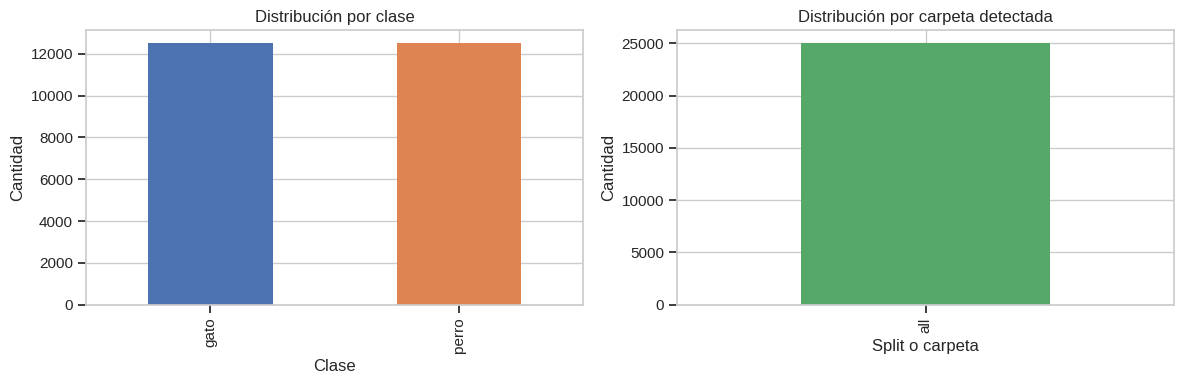

In [64]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
LABEL_ALIASES = {
    'cat': 'gato', 'cats': 'gato', 'gato': 'gato',
    'dog': 'perro', 'dogs': 'perro', 'perro': 'perro'
}
SPLIT_ALIASES = ['train', 'training', 'val', 'valid', 'validation', 'test']

def build_index(root_path):
    rows = []
    for file_path in root_path.rglob('*'):
        if file_path.suffix.lower() not in IMAGE_EXTS:
            continue
        parent_names = [parent.name.lower() for parent in file_path.parents]
        label = None
        for folder_name in parent_names:
            if folder_name in LABEL_ALIASES:
                label = LABEL_ALIASES[folder_name]
                break
        if label is None:
            continue
        split = 'all'
        for folder_name in parent_names:
            if folder_name in SPLIT_ALIASES:
                split = folder_name
                break
        rows.append({'filepath': str(file_path), 'label': label, 'split': split})
    index_df = pd.DataFrame(rows)
    if index_df.empty:
        raise ValueError('No se encontraron imágenes etiquetadas dentro del dataset.')
    index_df['label_idx'] = index_df['label'].map({'gato': 0, 'perro': 1}).astype('int32')
    return index_df

index_df = build_index(dataset_path)
print('Muestras encontradas:', len(index_df))
display(index_df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
index_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribución por clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
index_df['split'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Distribución por carpeta detectada')
axes[1].set_xlabel('Split o carpeta')
axes[1].set_ylabel('Cantidad')
plt.tight_layout()

In [65]:
split_values = set(index_df['split'].unique())
has_official_split = any(value in split_values for value in ['train', 'training', 'val', 'valid', 'validation', 'test'])

if has_official_split:
    train_pool_df = index_df[index_df['split'].isin(['train', 'training'])].copy()
    val_df = index_df[index_df['split'].isin(['val', 'valid', 'validation'])].copy()
    test_df = index_df[index_df['split'].isin(['test'])].copy()

    if train_pool_df.empty:
        train_pool_df = index_df[index_df['split'] == 'all'].copy()

    if val_df.empty:
        train_df, val_df = train_test_split(
            train_pool_df,
            test_size=0.15,
            stratify=train_pool_df['label'],
            random_state=SEED,
        )
    else:
        train_df = train_pool_df

    if test_df.empty:
        train_df, test_df = train_test_split(
            train_df,
            test_size=0.15,
            stratify=train_df['label'],
            random_state=SEED,
        )
else:
    train_df, temp_df = train_test_split(
        index_df,
        test_size=0.30,
        stratify=index_df['label'],
        random_state=SEED,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df['label'],
        random_state=SEED,
    )

for df_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(df_name, len(df), df['label'].value_counts().to_dict())

class_names = ['gato', 'perro']
pet_root = dataset_path / 'PetImages'
full_ds = tf.keras.utils.image_dataset_from_directory(
    pet_root,
    labels='inferred',
    label_mode='binary',
    class_names=['Cat', 'Dog'],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

cardinality = tf.data.experimental.cardinality(full_ds).numpy()
train_batches = int(cardinality * 0.70)
val_batches = int(cardinality * 0.15)

train_ds = full_ds.take(train_batches).prefetch(AUTOTUNE)
remaining_ds = full_ds.skip(train_batches)
val_ds = remaining_ds.take(val_batches).prefetch(AUTOTUNE)
test_ds = remaining_ds.skip(val_batches).prefetch(AUTOTUNE)

print('Batches totales:', cardinality)
print('Batches train/val/test:', train_batches, val_batches, cardinality - train_batches - val_batches)
print('Datasets preparados.')

train 17498 {'perro': 8749, 'gato': 8749}
val 3750 {'perro': 1875, 'gato': 1875}
test 3750 {'perro': 1875, 'gato': 1875}
Found 24998 files belonging to 2 classes.
Batches totales: 391
Batches train/val/test: 273 58 60
Datasets preparados.


In [66]:
def predecir_imagen_desde_array(image_array):
    image = tf.image.resize(image_array, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    prob = float(model.predict(image[None, ...], verbose=0)[0][0])
    label = 'perro' if prob >= 0.5 else 'gato'
    confidence = prob if prob >= 0.5 else 1 - prob
    return label, prob, confidence

def clasificar_subida():
    uploader = widgets.FileUpload(accept='image/*', multiple=False)
    boton = widgets.Button(description='Clasificar imagen', button_style='primary')
    salida = widgets.Output()

    def on_click(_):
        with salida:
            salida.clear_output()
            if not uploader.value:
                print('Sube una imagen primero.')
                return
            uploaded = uploader.value
            if isinstance(uploaded, dict):
                file_info = next(iter(uploaded.values()))
            else:
                file_info = uploaded[0]
            content = file_info['content'] if isinstance(file_info, dict) else file_info.content
            image = Image.open(io.BytesIO(content)).convert('RGB')
            image_array = tf.convert_to_tensor(np.array(image))
            label, prob, confidence = predecir_imagen_desde_array(image_array)

            plt.figure(figsize=(6, 6))
            plt.imshow(image)
            plt.axis('off')
            plt.title(f'Predicción: {label} | confianza: {confidence:.2%}')
            plt.show()

            print(f'Probabilidad de perro: {prob:.4f}')
            print(f'Predicción final: {label}')

    boton.on_click(on_click)
    display(widgets.VBox([widgets.HTML('<b>Sube una imagen externa para clasificarla</b>'), uploader, boton, salida]))

clasificar_subida()

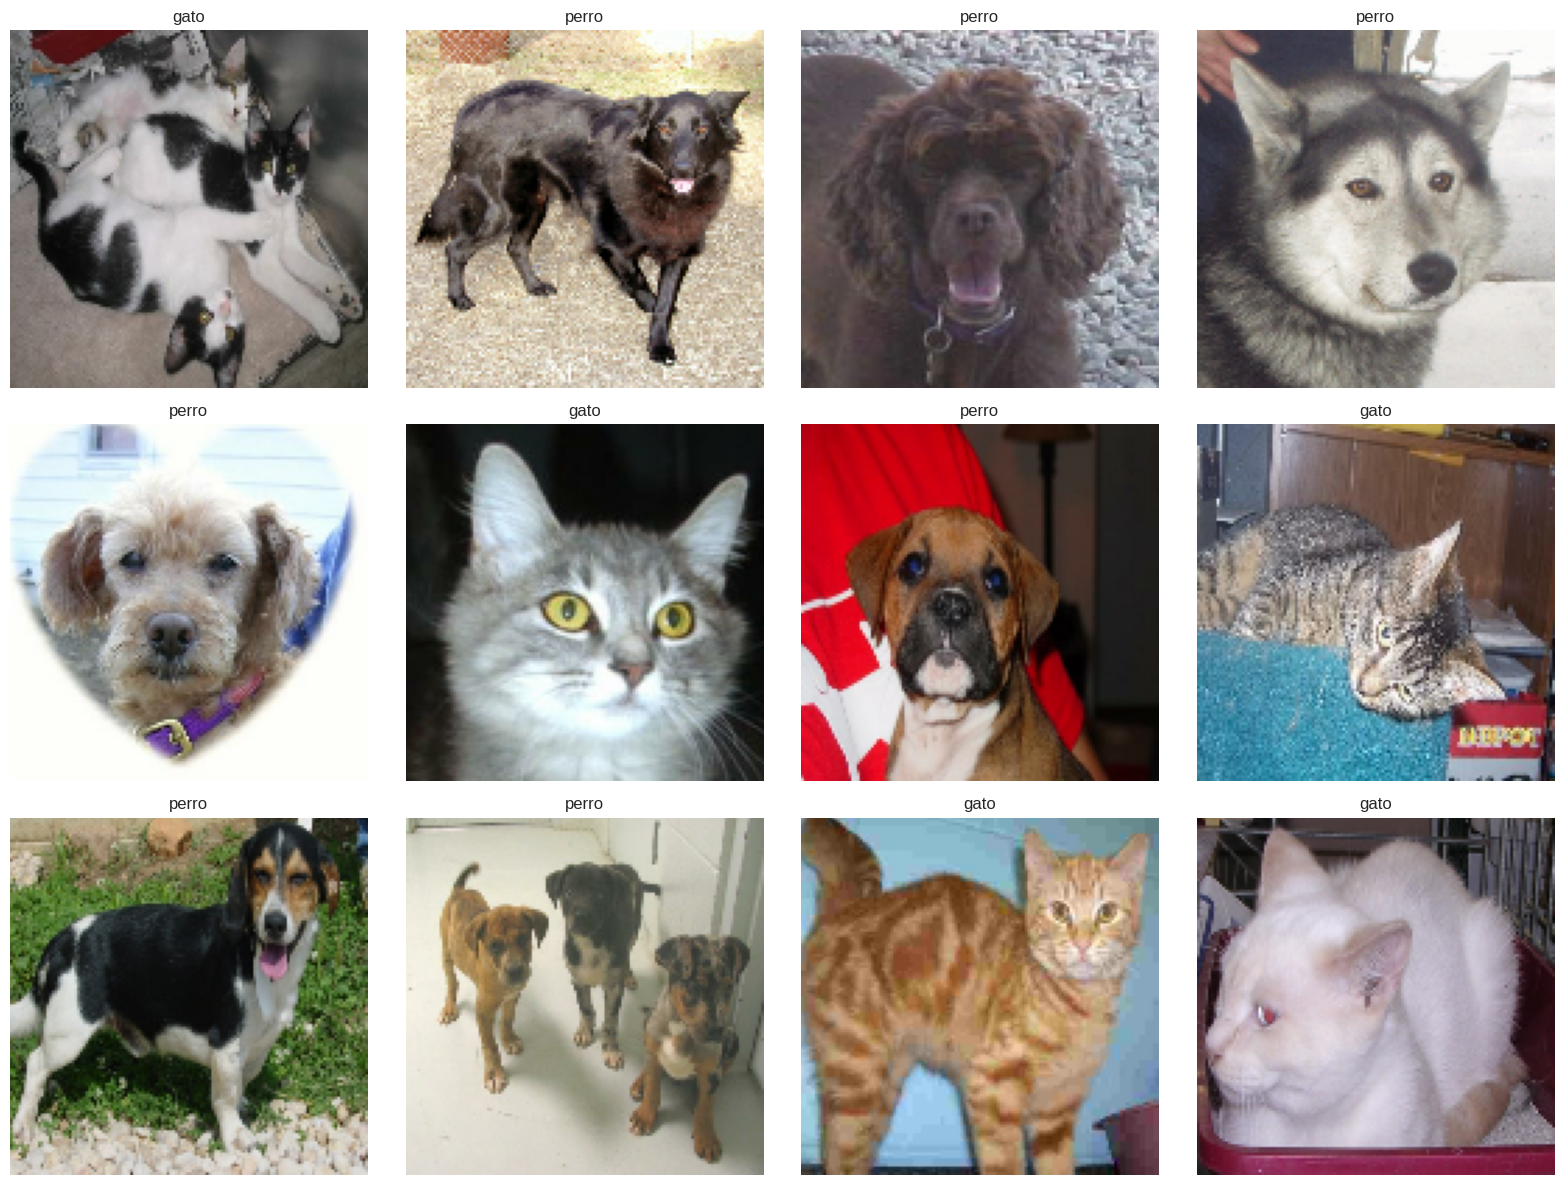

In [67]:
def mostrar_lote(dataset, n=12):
    images, labels = next(iter(dataset))
    n = min(n, images.shape[0])
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(np.clip(images[i].numpy().astype('uint8'), 0, 255))
        label_idx = int(labels[i].numpy())
        plt.title(class_names[label_idx])
        plt.axis('off')
    plt.tight_layout()

mostrar_lote(train_ds, n=12)

In [68]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255.0)(x)

for filtros in [32, 64, 128]:
    x = layers.Conv2D(filtros, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.40)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name='cnn_gatos_perros')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

model.summary()

Model: "cnn_gatos_perros"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5
  8/273 ━━━━━━━━━━━━━━━━━━━━ 13:57 3s/step - accuracy: 0.5180 - auc: 0.5053 - loss: 0.8752

In [ ]:
def plot_history(history_obj):
    history_dict = history_obj.history
    epochs = range(1, len(history_dict['loss']) + 1)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['accuracy'], label='Entrenamiento')
    plt.plot(epochs, history_dict['val_accuracy'], label='Validación')
    plt.title('Accuracy por época')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['loss'], label='Entrenamiento')
    plt.plot(epochs, history_dict['val_loss'], label='Validación')
    plt.title('Loss por época')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()

plot_history(history)

In [ ]:
test_probs = model.predict(test_ds, verbose=0).ravel()
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).astype(int)
y_pred = (test_probs >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
accuracy_test = (y_true == y_pred).mean()
print(f'Accuracy de test: {accuracy_test:.4f}')
print(report)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.tight_layout()

fpr, tpr, _ = roc_curve(y_true, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()

In [ ]:
test_paths = test_df['filepath'].values

def mostrar_ejemplos(indices, titulo, max_ejemplos=12):
    indices = list(indices)[:max_ejemplos]
    if len(indices) == 0:
        print(f'No se encontraron ejemplos para: {titulo}')
        return
    cols = 4
    rows = int(np.ceil(len(indices) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, idx in enumerate(indices):
        ax = plt.subplot(rows, cols, i + 1)
        img = Image.open(test_paths[idx]).convert('RGB')
        plt.imshow(img)
        real = class_names[y_true[idx]]
        pred = class_names[y_pred[idx]]
        color = 'green' if y_true[idx] == y_pred[idx] else 'red'
        plt.title(f'R: {real} | P: {pred}', color=color)
        plt.axis('off')
    plt.suptitle(titulo, y=1.02, fontsize=16)
    plt.tight_layout()

mostrar_ejemplos(np.where(y_true == y_pred)[0], 'Predicciones correctas')
mostrar_ejemplos(np.where(y_true != y_pred)[0], 'Predicciones incorrectas')

## Conclusiones

El notebook deja el flujo completo para entrenar, evaluar y usar un clasificador de gatos y perros con una CNN desde cero. Si el rendimiento final no fuera suficiente, la siguiente mejora natural sería probar transfer learning, pero en esta versión se mantiene el enfoque más cercano al notebook de referencia.